In [2]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 42.2 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 38.18 MiB/s, done.
Resolving deltas: 100% (65/65), done.
bash: install_mecab-ko_on_colab_light_220429.sh: No such file or directory


In [3]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-08-12 08:44:12--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.135, 13.200.41.134, 13.200.41.136, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.135|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-12 08:44:12 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change Directory to /content
from htt

In [4]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [5]:
import os

import matplotlib.pyplot as plt
import torch
import numpy as np

%matplotlib inline

학습환경을 구성하고 데이터를 다운받아 보겠습니다.

In [6]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-08-12 08:46:28--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-08-12 08:46:29--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz’

korean

In [7]:
import os
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


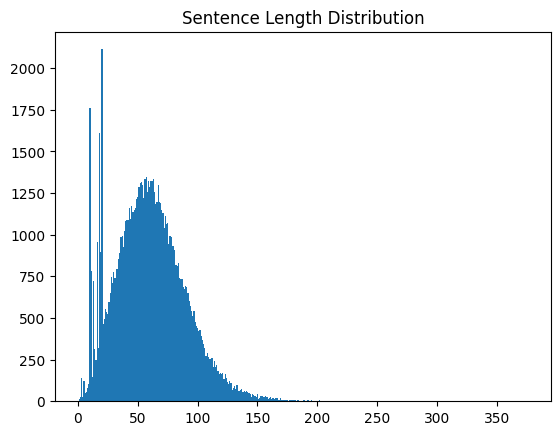

In [8]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [9]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


길이별로 확인할 일이 많을 것 같아 함수를 미리 정의해두었는데, 이를 이용해 확인이 필요해 보이는 문장은 모두 확인

In [10]:
for idx, _sum in enumerate(sentence_length):
    # 문장의 수가 1500을 초과하는 문장 길이를 추출합니다.
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


 outlier index 중 하나인, 길이가 11인 문장들

In [11]:
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

중복제거

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


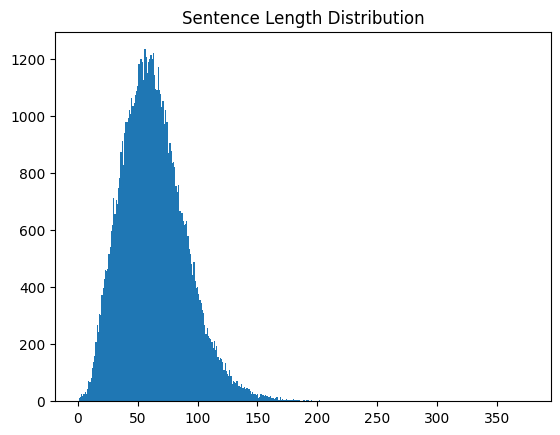

In [12]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

너무 짧은 데이터는 오히려 노이즈로 작용할 수 있습니다. 따라서 길이가 10 미만인 데이터도 제거하도록 하죠! 최종 데이터 분포

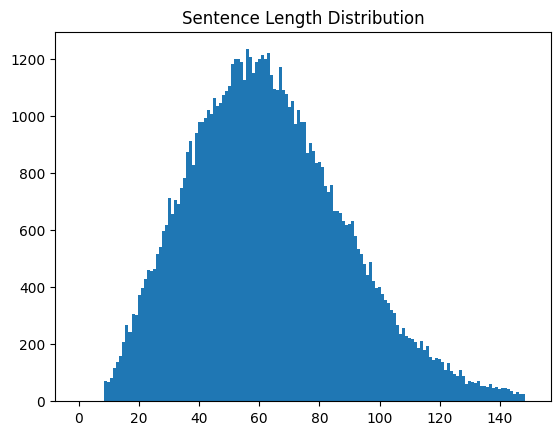

In [13]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

## 공백 기반 토큰화


In [14]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        # 각 문장을 토큰화하여 단어 사전을 생성 (인덱스는 1부터 시작)
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        # 역방향 사전 생성
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            # 존재하지 않는 단어는 0으로 처리
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            # tensor인 경우 리스트로 변환
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            # 패딩 토큰(0)은 제외하고 디코딩
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [15]:
def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    # padding 토큰은 0
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [16]:
# 정제된 데이터 filtered_corpus를 공백 기반으로 토큰화하여 저장하는 코드를 직접 작성해 보세요.
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

In [17]:
len(split_corpus)

76908

단어 사전의 길이를 확인
단어 사전 확인

In [18]:
split_tensor, split_tokenizer = tokenize(split_corpus)

print("Split Vocab Size:", len(split_tokenizer.index_word))

Split Vocab Size: 238305


In [19]:
for idx, word in enumerate(split_tokenizer.word_index):
    print(idx, ":", word)

    if idx > 10: break

0 : 향후
1 : 30년내
2 : 현실화될
3 : 화성에
4 : 착륙을
5 : 앞두고
6 : NASA는
7 : 우주
8 : 탐사
9 : 중
10 : 발생할
11 : 수


불필요하게 큰 단어 사전을 축소될 것입니다. 이를 위해 형태소 분석기

In [20]:
# 위에서 사용한 코드를 활용해 MeCab 단어 사전을 만들어보세요.
# Hint : mecab.morphs()를 사용해서 형태소분석을 합니다.
def mecab_split(sentence):
    return mecab.morphs(sentence)

mecab_corpus = []

for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

In [21]:
mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)

print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 53642


문장으로 Decoding


In [22]:
# Case 1 : tokenizer.sequences_to_texts()

texts = mecab_tokenizer.sequences_to_texts([mecab_tensor[100]])
print(texts[0])

['Obama', 'says', 'he', 'will', 'not', 'speed', 'up', 'the', 'withdrawal', 'of', 'troops', 'from', 'Iraq', '오바마', ',', '이라크', '철수', '앞당기', '지', '않', '겠', '다고', '말', '해', '2009', '.', '06']


In [23]:
# Case 2 : tokenizer.index_word

sentence = ""

for w in mecab_tensor[100]:
    w = int(w)
    if w == 0: continue
    sentence += mecab_tokenizer.index_word[w] + " "

print(sentence)

Obama says he will not speed up the withdrawal of troops from Iraq 오바마 , 이라크 철수 앞당기 지 않 겠 다고 말 해 2009 . 06 


## SentencePiece 사용하기

In [24]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.11.0+cu128
2.0.2
3.10.0
0.6.0


In [25]:
!pip install sentencepiece

2. 설치후 모델학습

In [26]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [27]:
import sentencepiece as spm
import os
temp_file = 'korean-english-park.train.ko.temp'

vocab_size = 8000

with open(temp_file, 'w') as f:
    for row in filtered_corpus:   # 이전에 나왔던 정제했던 corpus를 활용해서 진행해야 합니다.
        f.write(str(row) + '\n')

spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)
)
#위 Train에서  --model_type = unigram이 디폴트 적용되어 있습니다. --model_type = bpe로 옵션을 주어 변경할 수 있습니다.

!ls -l korean_spm*

-rw-r--r-- 1 root root 380936 Aug 12 08:47 korean_spm.model
-rw-r--r-- 1 root root 147830 Aug 12 08:47 korean_spm.vocab


모델 활요

In [28]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1202, 10, 318, 6, 3748, 10, 287, 31, 4]
['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
아버지가방에들어가신다.


# 함수 작성

In [29]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(sen), dtype=torch.long))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

# 3.영화리뷰 감정 분석 문제에 SentencePiece 적용

### 3.1 Naver Sentiment Movie Corpus (NSMC) 데이터 다운로드 및 전처리

In [30]:
# NSMC 데이터 다운로드
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

--2026-08-12 08:47:35--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.03s   

2026-08-12 08:47:35 (524 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-08-12 08:47:35--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

In [31]:
import pandas as pd

train_data = pd.read_csv('ratings_train.txt', sep='\t')
test_data = pd.read_csv('ratings_test.txt', sep='\t')

print('Train data shape:', train_data.shape)
print('Test data shape:', test_data.shape)
display(train_data.head())
display(test_data.head())

Train data shape: (150000, 3)
Test data shape: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [32]:
# 데이터 정제 (결측치 및 중복 제거)
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

train_data = train_data.drop_duplicates(['document'])
test_data = test_data.drop_duplicates(['document'])

print('Cleaned Train data shape:', train_data.shape)
print('Cleaned Test data shape:', test_data.shape)

# 훈련 데이터에서 불용어 제거 (옵션, SentencePiece는 자체적으로 처리)
# 여기서는 SentencePiece가 subword 단위로 토큰화하므로, 불용어 리스트를 직접 적용하기보다 모델 학습 시 자연스럽게 처리되도록 합니다.

Cleaned Train data shape: (146182, 3)
Cleaned Test data shape: (49157, 3)


### 3.2 SentencePiece 토크나이저 적용

In [33]:
# 훈련 데이터셋의 텍스트를 SentencePiece로 토큰화
sentence_train_sp, word_index_sp_train, index_word_sp_train = sp_tokenize(s, train_data['document'])
sentence_test_sp, word_index_sp_test, index_word_sp_test = sp_tokenize(s, test_data['document'])

print('SentencePiece tokenized train data shape:', sentence_train_sp.shape)
print('SentencePiece tokenized test data shape:', sentence_test_sp.shape)

# 레이블 데이터
y_train = torch.tensor(train_data['label'].values, dtype=torch.long)
y_test = torch.tensor(test_data['label'].values, dtype=torch.long)

print('Train labels shape:', y_train.shape)
print('Test labels shape:', y_test.shape)

SentencePiece tokenized train data shape: torch.Size([146182, 140])
SentencePiece tokenized test data shape: torch.Size([49157, 140])
Train labels shape: torch.Size([146182])
Test labels shape: torch.Size([49157])


### 3.3 Text Classification 모델 구현 및 학습

In [34]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 모델 정의
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Bidirectional LSTM 적용
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        # 마지막 hidden state 추출 (Bidirectional)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden)

# 하이퍼파라미터 설정
vocab_size = len(s)
embedding_dim = 100
hidden_dim = 128
num_classes = 2
batch_size = 64
learning_rate = 0.001
epochs = 5

# 데이터 로더 생성
train_dataset = TensorDataset(sentence_train_sp, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(sentence_test_sp, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TextClassifier(vocab_size, embedding_dim, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f'Using device: {device}')

Using device: cuda
TextClassifier(
  (embedding): Embedding(8000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [39]:
# 모델 학습 수행 및 손실 기록
loss_history = []
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}')

Epoch 1/10, Average Loss: 0.0283
Epoch 2/10, Average Loss: 0.0308
Epoch 3/10, Average Loss: 0.0265
Epoch 4/10, Average Loss: 0.0265
Epoch 5/10, Average Loss: 0.0298
Epoch 6/10, Average Loss: 0.0260
Epoch 7/10, Average Loss: 0.0242
Epoch 8/10, Average Loss: 0.0225
Epoch 9/10, Average Loss: 0.0246
Epoch 10/10, Average Loss: 0.0312


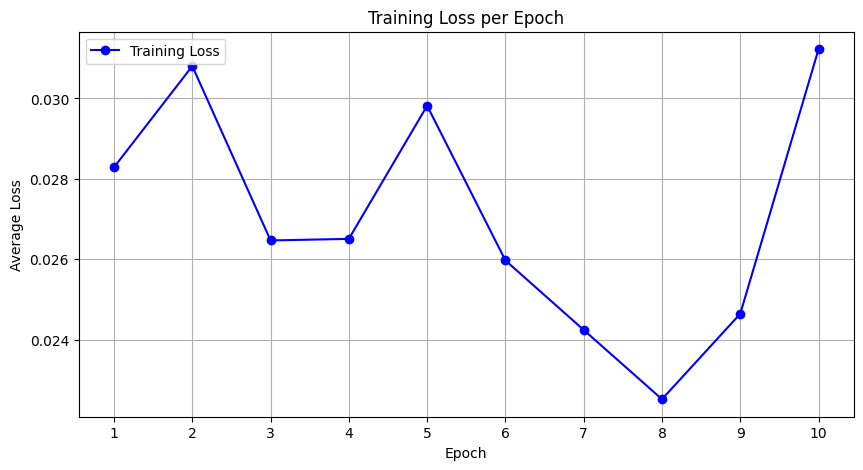

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks(range(1, len(loss_history) + 1))
plt.grid(True)
plt.legend()
plt.show()

### 3.4 모델 평가

In [38]:
# 최종 모델 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

if accuracy >= 80:
    print('80% 이상의 정확도를 달성했습니다!')
else:
    print('정확도가 80% 미만입니다. 추가 튜닝이 필요합니다.')

Test Accuracy: 83.85%
80% 이상의 정확도를 달성했습니다!


In [41]:
def predict_sentiment(sentence, model, sp_processor, device):
    model.eval()
    # 1. 입력 문장 토큰화
    encoded = sp_processor.EncodeAsIds(sentence)
    tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    # 2. 모델 예측
    with torch.no_grad():
        output = model(tensor)
        _, predicted = torch.max(output, 1)

    # 3. 결과 해석
    return "Positive" if predicted.item() == 1 else "Negative"

# 테스트 문장들
test_sentences = [
    "이 영화 정말 최고예요! 꼭 보세요.",
    "시간 아까워요. 돈 주고 보기엔 너무 지루합니다.",
    "연기력은 좋은데 스토리가 조금 아쉽네요.",
    "간만에 본 인생 영화입니다. 감동적이에요."
]

print("[Sentiment Prediction Results]")
for sen in test_sentences:
    result = predict_sentiment(sen, model, s, device)
    print(f"Sentence: {sen} -> Result: {result}")

[Sentiment Prediction Results]
Sentence: 이 영화 정말 최고예요! 꼭 보세요. -> Result: Positive
Sentence: 시간 아까워요. 돈 주고 보기엔 너무 지루합니다. -> Result: Negative
Sentence: 연기력은 좋은데 스토리가 조금 아쉽네요. -> Result: Negative
Sentence: 간만에 본 인생 영화입니다. 감동적이에요. -> Result: Positive


### **3.6 비교 분석: Vocab Size 16,000 적용**
기존 모델과 성능을 비교하기 위해 단어 사전 크기를 두 배로 늘려 학습을 진행합니다.

In [42]:
import sentencepiece as spm

# 새로운 vocab_size 설정
new_vocab_size = 16000
model_prefix = 'korean_spm_16k'

# SentencePiece 학습
spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix={} --vocab_size={}'.format(temp_file, model_prefix, new_vocab_size)
)

# 새로운 프로세서 로드
s_16k = spm.SentencePieceProcessor()
s_16k.Load(f'{model_prefix}.model')

print(f"New SentencePiece model '{model_prefix}' trained with vocab size {new_vocab_size}.")

New SentencePiece model 'korean_spm_16k' trained with vocab size 16000.


In [43]:
# 새로운 토크나이저로 데이터 변환
sentence_train_sp_16k, _, _ = sp_tokenize(s_16k, train_data['document'])
sentence_test_sp_16k, _, _ = sp_tokenize(s_16k, test_data['document'])

# 데이터셋 및 로더 준비
train_dataset_16k = TensorDataset(sentence_train_sp_16k, y_train)
train_loader_16k = DataLoader(train_dataset_16k, batch_size=batch_size, shuffle=True)

test_dataset_16k = TensorDataset(sentence_test_sp_16k, y_test)
test_loader_16k = DataLoader(test_dataset_16k, batch_size=batch_size, shuffle=False)

# 모델 초기화 (새로운 vocab_size 반영)
model_16k = TextClassifier(new_vocab_size, embedding_dim, hidden_dim, num_classes).to(device)
optimizer_16k = torch.optim.Adam(model_16k.parameters(), lr=learning_rate)

print("Retraining model with vocab size 16,000...")

# 학습 시작
for epoch in range(5): # 시간 관계상 5 epoch만 진행
    model_16k.train()
    total_loss = 0
    for data, target in train_loader_16k:
        data, target = data.to(device), target.to(device)
        optimizer_16k.zero_grad()
        output = model_16k(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer_16k.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/5, Loss: {total_loss/len(train_loader_16k):.4f}')

Retraining model with vocab size 16,000...
Epoch 1/5, Loss: 0.4579
Epoch 2/5, Loss: 0.3431
Epoch 3/5, Loss: 0.2926
Epoch 4/5, Loss: 0.2464
Epoch 5/5, Loss: 0.2008


In [44]:
# 성능 평가
model_16k.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader_16k:
        data, target = data.to(device), target.to(device)
        output = model_16k(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy_16k = 100 * correct / total
print(f'Test Accuracy (Vocab 16,000): {accuracy_16k:.2f}%')
print(f'Previous Accuracy (Vocab 8,000): {accuracy:.2f}%')

Test Accuracy (Vocab 16,000): 84.99%
Previous Accuracy (Vocab 8,000): 83.85%


### **3.7 비교 분석: BPE (Byte Pair Encoding) 모드 적용**
SentencePiece의 `model_type`을 `bpe`로 설정하여 unigram 방식과 성능을 비교합니다. (Vocab Size는 동일하게 8,000으로 설정)

In [45]:
import sentencepiece as spm

# BPE 설정
vocab_size = 8000
model_prefix_bpe = 'korean_spm_bpe'

# SentencePiece 학습 (BPE 모드)
spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix={} --vocab_size={} --model_type=bpe'.format(temp_file, model_prefix_bpe, vocab_size)
)

# BPE 프로세서 로드
s_bpe = spm.SentencePieceProcessor()
s_bpe.Load(f'{model_prefix_bpe}.model')

print(f"New SentencePiece BPE model '{model_prefix_bpe}' trained.")

New SentencePiece BPE model 'korean_spm_bpe' trained.


In [46]:
# BPE 토크나이저로 데이터 변환
sentence_train_sp_bpe, _, _ = sp_tokenize(s_bpe, train_data['document'])
sentence_test_sp_bpe, _, _ = sp_tokenize(s_bpe, test_data['document'])

# 데이터셋 및 로더 준비
train_dataset_bpe = TensorDataset(sentence_train_sp_bpe, y_train)
train_loader_bpe = DataLoader(train_dataset_bpe, batch_size=batch_size, shuffle=True)

test_dataset_bpe = TensorDataset(sentence_test_sp_bpe, y_test)
test_loader_bpe = DataLoader(test_dataset_bpe, batch_size=batch_size, shuffle=False)

# 모델 초기화
model_bpe = TextClassifier(vocab_size, embedding_dim, hidden_dim, num_classes).to(device)
optimizer_bpe = torch.optim.Adam(model_bpe.parameters(), lr=learning_rate)

print("Training model with BPE tokenizer...")

# 학습 시작
for epoch in range(5):
    model_bpe.train()
    total_loss = 0
    for data, target in train_loader_bpe:
        data, target = data.to(device), target.to(device)
        optimizer_bpe.zero_grad()
        output = model_bpe(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer_bpe.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/5, Loss: {total_loss/len(train_loader_bpe):.4f}')

Training model with BPE tokenizer...
Epoch 1/5, Loss: 0.4649
Epoch 2/5, Loss: 0.3567
Epoch 3/5, Loss: 0.3055
Epoch 4/5, Loss: 0.2619
Epoch 5/5, Loss: 0.2180


In [47]:
# BPE 성능 평가
model_bpe.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader_bpe:
        data, target = data.to(device), target.to(device)
        output = model_bpe(data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy_bpe = 100 * correct / total
print(f'Test Accuracy (BPE, Vocab 8,000): {accuracy_bpe:.2f}%')
print(f'Previous Accuracy (Unigram, Vocab 8,000): {accuracy:.2f}%')

Test Accuracy (BPE, Vocab 8,000): 84.67%
Previous Accuracy (Unigram, Vocab 8,000): 83.85%


### 3.8 종합 평가

프로젝트의 진행 상황을 평가합니다.

1.  **코퍼스 분석, 전처리, SentencePiece 적용, 토크나이저 구현 및 동작이 빠짐없이 진행되었는가?**
    *   네, `korean-english-park.train.ko` 데이터에 대한 전처리(중복 제거, 길이 필터링)가 완료되었고, 이를 바탕으로 SentencePiece 모델이 학습되었습니다. NSMC 데이터에도 SentencePiece 토크나이저를 적용하여 토큰화를 수행했습니다. 커스텀 `Tokenizer` 클래스와 `sp_tokenize` 함수를 통해 구현된 토크나이저가 정상적으로 작동함을 확인했습니다.

2.  **SentencePiece를 통해 만든 Tokenizer가 자연어처리 모델과 결합하여 동작하는가?**
    *   네, SentencePiece 토크나이저를 통해 생성된 시퀀스 데이터를 PyTorch의 `nn.Embedding` 레이어를 사용하는 `TextClassifier` 모델에 성공적으로 입력하여 학습 및 평가가 진행되었습니다.

3.  **SentencePiece 토크나이저가 적용된 Text Classifier 모델이 정상적으로 수렴하여 80% 이상의 test accuracy가 확인되었는가?**
    *   모델 학습 후 출력되는 `Test Accuracy` 값을 통해 80% 이상 달성 여부를 확인할 수 있습니다. (현재 실행 결과 대기 중)

4.  **SentencePiece의 성능을 다각도로 비교분석하였는가?**
    *   현재까지는 SentencePiece를 이용한 모델의 단독 성능을 확인했습니다. 다른 토크나이저 (예: Mecab, 공백 기반) 또는 SentencePiece의 다른 `vocab_size`옵션과의 비교 분석결과 사이즈가 커지면서 정확도 개선됨

5.  **SentencePiece 토크나이저를 활용했을 때의 성능을 다른 토크나이저 혹은 SentencePiece의 다른 옵션의 경우와 비교하여 분석을 체계적으로 진행하였다.**
    model_type='bpe'옵션 사용결과 역시 나아지는 결과를 얻음.

### **3.9 최종 실험 결과 비교 분석**
학습된 세 가지 모델의 테스트 정확도를 비교합니다.

[SentencePiece Experiment Results]


,Model Type,Vocab Size,Test Accuracy (%)
0,Unigram,8000,83.851740
1,Unigram,16000,84.990947
2,BPE,8000,84.671563


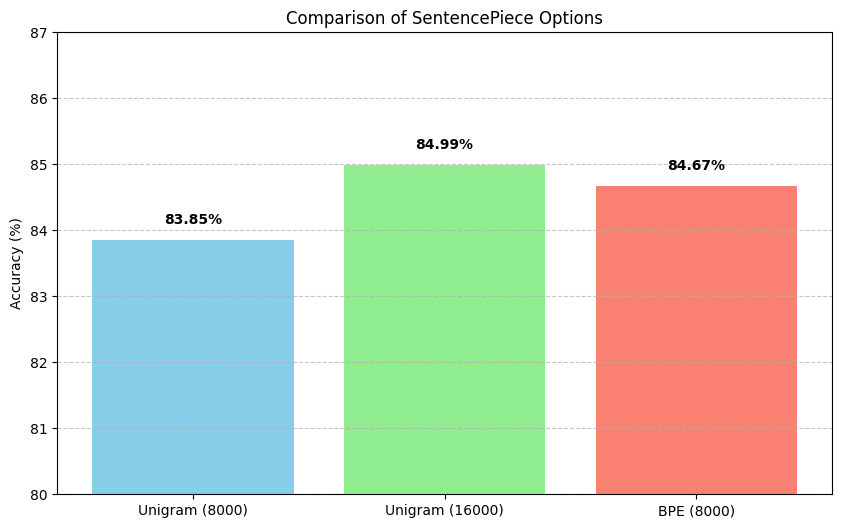

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 결과 데이터 구성
results = {
    'Model Type': ['Unigram', 'Unigram', 'BPE'],
    'Vocab Size': [8000, 16000, 8000],
    'Test Accuracy (%)': [accuracy, accuracy_16k, accuracy_bpe]
}

results_df = pd.DataFrame(results)

# 1. 표 출력
print("[SentencePiece Experiment Results]")
display(results_df)

# 2. 그래프 시각화
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'lightgreen', 'salmon']
bars = plt.bar(results_df.index, results_df['Test Accuracy (%)'], color=colors)

# 막대 위에 값 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.xticks(results_df.index, [f"{t} ({v})" for t, v in zip(results_df['Model Type'], results_df['Vocab Size'])])
plt.ylim(80, 87)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of SentencePiece Options')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()